# 합성곱 신경망 (CNN) : 이미지 인식의 혁신
- 이미지는 픽셀 간의 공간적 관계 중요
- MLP: 픽셀을 일렬로 펼쳐 처리
- CNN: 이미지의 2차원 구조를 유지한 채 주변 픽셀 관계와 시각적 특징을 학습
- **이미지 구조 유지 → CNN**

## CNN
- Convolution으로 특징(feature) 추출: 모델이 ‘특징’을 학습
- Pooling으로 차원 축소: 위치/크기 변화에 덜 민감하게 함
- 어떤 영역에 특정한 특징이 존재하는가를 보기 때문에 위치에 무관

> ### CNN을 이용한 이미지 처리 구조

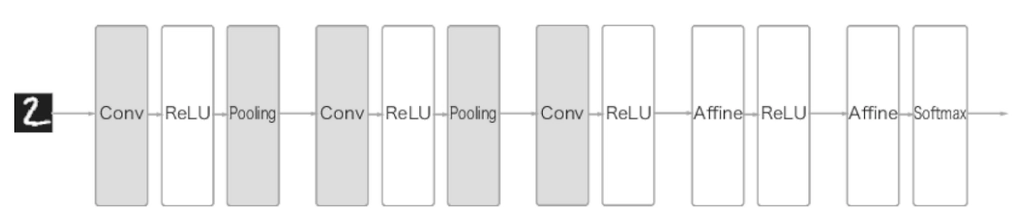 
- 부분연결 구조 & Convolution 연산으로 이미지의 특정 피쳐에만 집중
- 효율적인 파라미터 사용: 위 예시에서 파라미터 수가 1000배 차이

> ### CNN의 공간 정보 손실
- 다차원 이미지를 그대로 입력받고, 공간 정보를 보존하면서 학습
- 특징을 어느 정도 추출한 후 flatten 하기 때문에, 그 손실의 정도가 훨씬 낮음

## CNN 모델

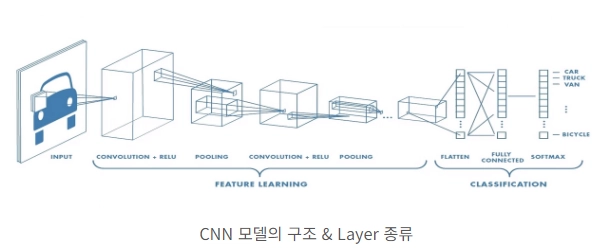
- CNN 모델은 위 이미지와 같이 이미지의 위치 별 특징을 추출(Feature Learning)하는 부분과 클래스를 분류하는 부분(Classification)으로 나눌 수 있음

- 특징 추출(Feature learning) 영역: Convolution Layer와 Pooling Layer를 여러 겹 쌓는 형태로 구성
    - Convolution Layer: 입력 데이터에 필터를 적용 후 활성화 함수를 반영하는 필수 요소
    - Pooling Layer: Convolution Layer 다음에 위치하며, 이미지의 공간 크기를 줄여 중요한 특징을 강조하는 역할. 모델의 계산 효율성을 높이고, 과적합을 방지하는 데 도움을 줌.
- 이미지 분류(Classification)를 하는 영역: CNN 모델의 마지막에 위치하고 Fully Connected Layer로 구성
- Feature Learning(Conv + Pool)과 Classification(FC Layer) 사이에 3차원을 1차원 배열 형태로 만드는 Flatten 위치 

### CNN모델의 두 분류
1. **특징 추출 (Feature Learning)** - **Convolution,** **Pooling**이 담당
2. **클래스 분류 (Classification)** - **Fully Connected Layer**가 담당

> #### Convolution Layer
- 전체 이미지를 일정 크기의 필터로 훑으면서 이미지의 특징을 학습

1. 필터(Filter) 또는 커널(Kernel)이 이미지 위를 슬라이딩
    - CNN의 필터 값은 MLP의 가중치(weight)와 같은 역할을 함
2. 각 위치에서 요소별 곱셈 후 합계 계산
3. 결과를 Feature Map에 저장
    - feature map: input data에 filter를 적용하여 얻은 결과물
    - feature map의 차원은 filter의 수에 따라 결정됨.
    (활성화된 정도를 나타낸다는 점에서 activation map이라고도 부름)

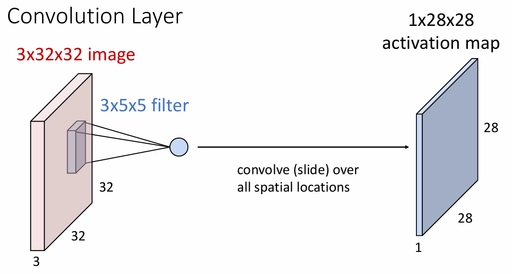
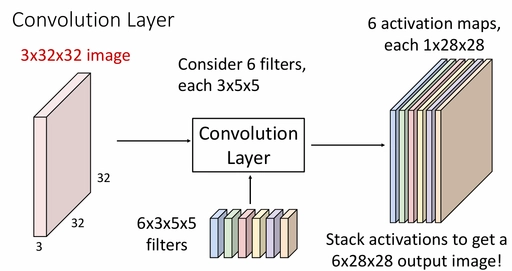

> #### Padding
- filter를 거치며 정보를 잃어버리는 것을 막기 위해 이미지 바깥을 0으로 둘러싸는 기법

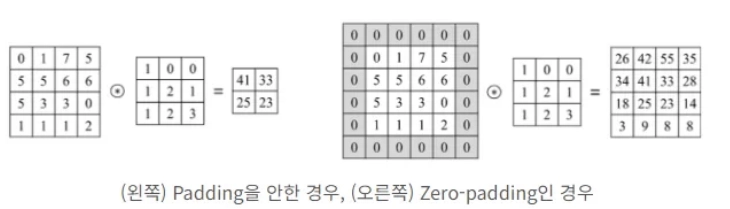
- adding=1로 설정했을 의 연산 과정
- padding을 적용하지 않은 경우 feature map의 크기는 2x2 → padding 적용시 4x4
- → 이미지 크기를 유지하면서 가장자리 특징까지 반영할 수 있다.

> #### Stride (보폭)
- 이미지를 몇 칸씩 점프하면서 훑을 것인지 결정하는 값
- Stride = 1: 한 칸씩 이동 (세밀한 특징 추출)
- Stride = 2: 두 칸씩 이동 (빠른 처리, 크기 축소)
- → 계산량 감소, 겹치는 영역을 줄여 효율적으로 요약
- **⇒ stride가 커질 수록 feature map의 크기가 작아진다**

> #### Pooling
- 피처맵에서 특징을 추출하기 위해 이미지를 격자 형태로 분할한 뒤, 해당 영역 안에서 가장 큰 값 또는 평균값을 취하는 것

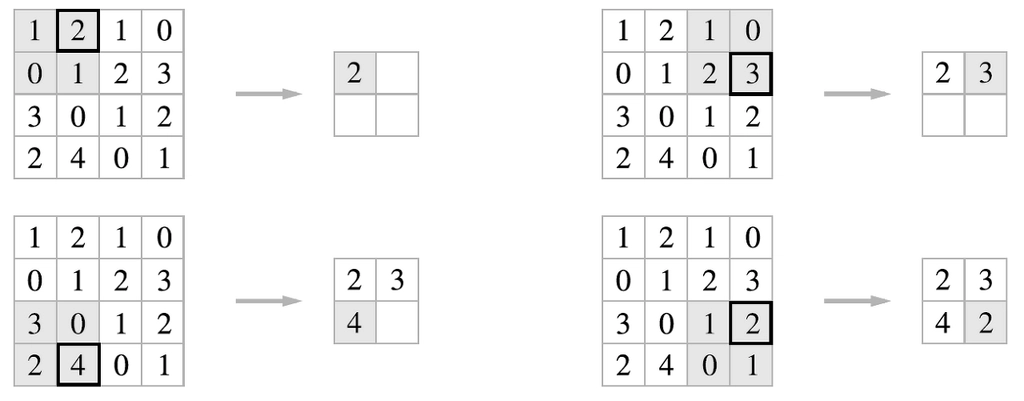
- max pooling을 적용한 연산 과정

# 이미지 딥러닝 응용
> ## 이미지 분류
[아이디어]
- 이미지를 수치 데이터(픽셀 값)로 인식 → 사전 정의된 클래스 중 하나로 분류

[모델별 정리]

| 모델명 | 특징 요약 | 주의사항 |
|:---:|:---|:---|
| **AlexNet** | 비교적 단순한 구조, 초기 CNN 모델의 표준 | 작은 데이터셋이나 학습 개념 설명용으로 적절 |
| **VGG** | 더 깊은 구조, 복잡한 블록 구조(3x3 필터 반복) 적용 | 계산량 증대, 메모리 요구 사항이 매우 높음 |
| **ResNet** | **Residual 연결 (Skip connections)** 도입 → 매우 깊은 층 구성 가능 | 과적합 주의, Batch Size 및 Regularization 세밀한 조절 필요 |
| **ViT** | **Transformer 구조 응용** → 이미지를 패치 기반으로 입력 처리 | 이미지와 순차 처리 모델의 결합, 성능 극대화를 위해 대규모 데이터 필수 |

> ## 객체 탐지
[아이디어]
- 객체 검출(object detection)은 한 이미지에서 객체와 이 객체를 둘러싸는 가장 작은 직사각형으로 정의되는 bounding box를 찾는 작업

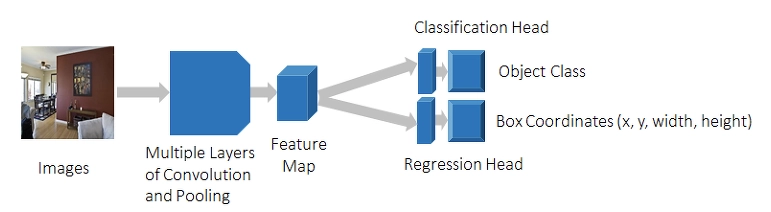
[모델 적용 방식]
- CNN을 통해 Feature Map을 얻고, 그 위에 두 가지 head를 올림:
    - Classification Head: 객체의 클래스 예측
    - Regression Head: 객체의 위치 (x, y, width, height) 좌표 예측
- 대표 모델: YOLO, Faster R-CNN, SSD 등

> ## 이미지 캡셔닝
[아이디어]
- image captioning은 이미지 내에 있는 객체에 대한 판단뿐만 아니라 객체들 간의 관계를 파악하고 자연어의 형태로 알맞게 표현

[모델 적용방식: CNN과 RNN]
- 이미지 특징을 추출하기 위한 CNN과 문장으로 나타내기 위한 RNN

[이미지 캡셔닝 단계]
- CNN을 이용한 특징 추출

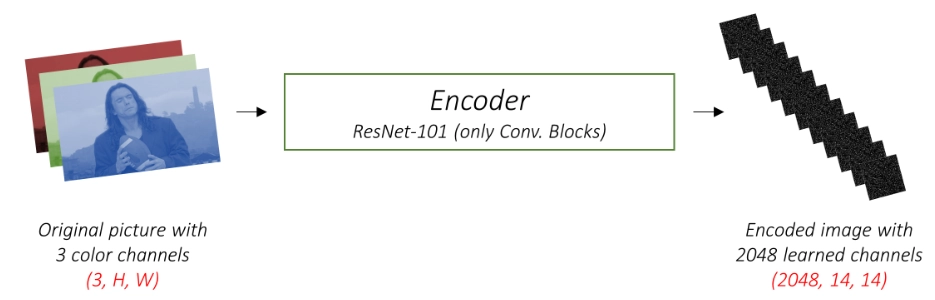
    - RGB 3채널의 인풋 데이터를 ResNet-101을 이용하여 특징을 추출

- Attention Network를 이용하여 단어 생성

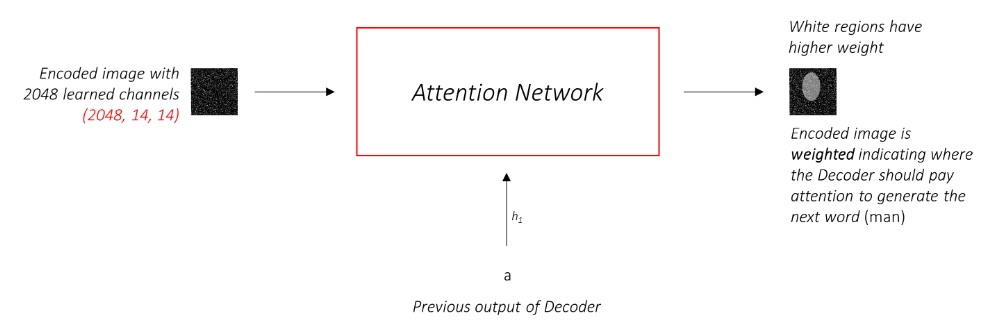
    - Attention Network를 통과하여 중요한 부분에 가중치를 두어 단어를 추출
    - 가중치가 높은 부분을 이용해 사진을 한 문장으로 설명할 수 있게 함.

- RNN을 이용하여 문장 완성

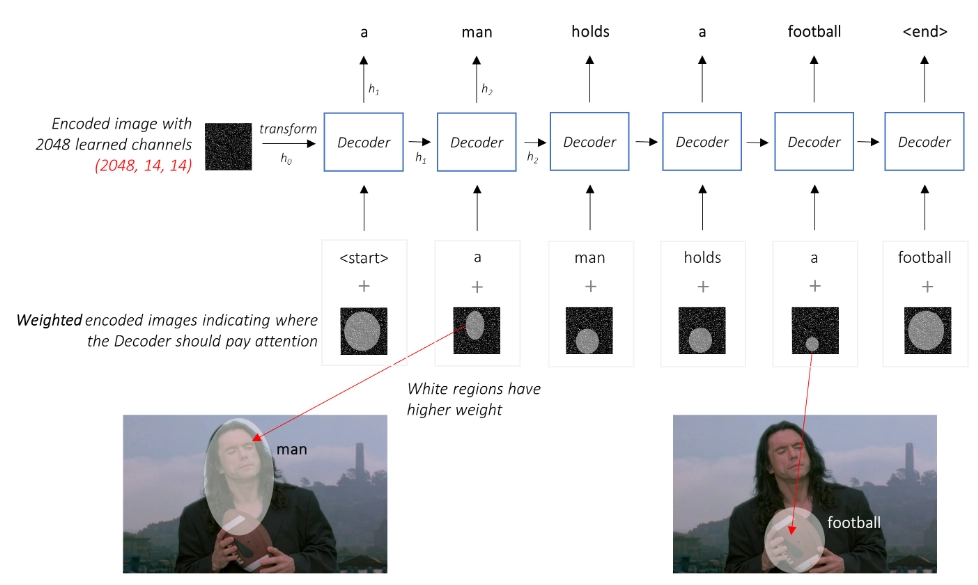
    - 가중치를 바탕으로 추출해낸 이미지의 주요 단어들을 RNN을 통해 조합하여 문장을 완성

# RNN
## RNN 구조와 원리
> ### RNN(Recurrent Neural Network)의 정의
- 순환하는 구조를 가진, 순차 데이터 처리에 특화된 인공 신경망
- “순환 신경망”

> ### RNN의 구조

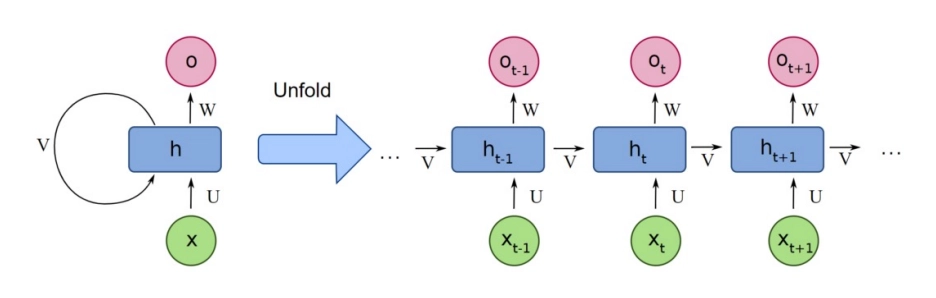
- 초록색은 **입력층**, 파란색은 **은닉층**, 분홍색은 **출력층**을 의미

- **용어 설명**
    - $x_t$: 시간  $t$에서의 **입력 (Input)**
    - $h_t$: 시간  $t$에서의 **은닉 상태 (Hidden State)**. 이 시점의 '**메모리**'입니다.
    - $o_t$: 시간  $t$에서의 **출력 (Output)**
    - $U$(**입력 가중치**):
        - 현재 시점  $t$의 입력($x_t$)이 은닉 상태($h_t$)에 영향을 주는 가중치
    - $V$(**순환 가중치**):
        - 이전 시점 $t-1$의 은닉 상태($h_{t-1}$)가 현재 은닉 상태에 영향을 주는 가중치
    - $W$(**출력 가중치**):
        - 현재 시점 $t$의 은닉 상태($h_{t}$)가 최종 출력($o_t$)에 영향을 미치는 가중치
        - 계산된 메모리를 바탕으로 **결과**를 만들어내는 역할
    - 기존 신경망과의 차이점
        - **V(순환 가중치)의 유무**
        
        우리가 기존에 배웠던 신경망의 이미지를 생각해 보면, 위 이미지에서의 V, 순환 가중치가 존재하지 않는다.
        즉, 입력층에서 은닉층을 거쳐 바로 출력층으로 이동한다.
        
        하지만 RNN에서는 V(순환 가중치)를 통해 이전 시점의 정보를 전달한다.
        위에서 적은 RNN을 뉴런 단위로 시각화하면 다음과 같다.
        
        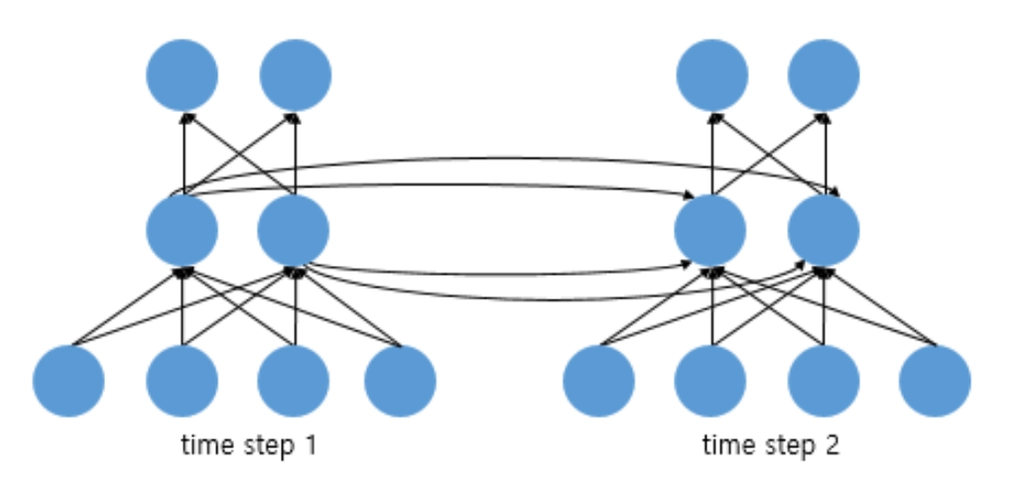
         - 기존 DNN(Deep Neural Network)에는 저 사이를 연결해주는 선이 없었음

- **정보 흐름**
    - **$t−1$  시점**: 입력 $x_{t-1}$이 들어가서 은닉 상태 $h_{t-1}$을 업데이트하고, 출력 $o_{t-1}$을 내보냄
    - **$t$  시점**:  $t−1$ 시점에서 계산된 **은닉 상태 $h_{t-1}$이 다음 시점으로 그대로 전달**
    - **새로운 입력** $x_t$와 전달받은 **과거 정보** $h_{t-1}$을 함께 사용하여 **현재 시점의 은닉 상태** $ht$를 업데이트하고, **출력** $o_t$를 계산

**⇒ 은닉 상태(Hidden State)의 순환을 통해 과거의 정보를 다음 시점으로 계속해서 전달**

> ### RNN의 핵심 원리: 가중치 공유
- 동일한 가중치를 시퀀스의 다양한 시점에서 반복적으로 적용
- RNN이 시퀀스 데이터의 길이와 시점 위치에 상관없이 효과적으로 작동하게 하는 핵심 원리

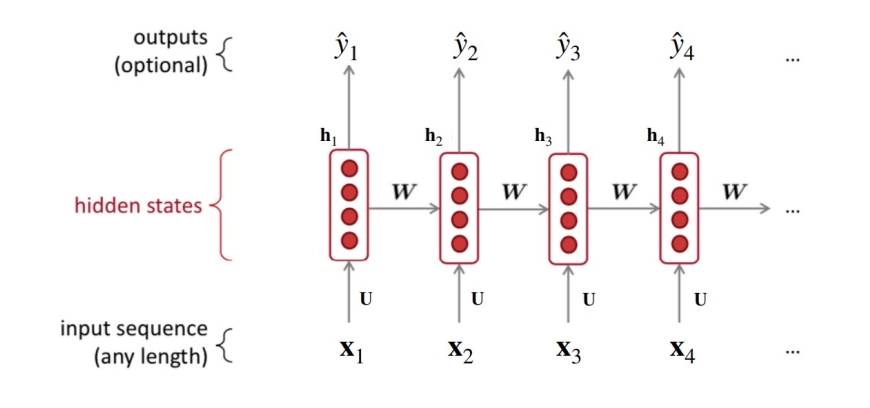

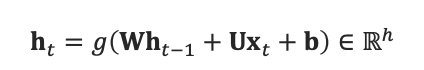
- $X_1$을 처리할 때, $X_2$를 처리할 때, 그리고 $X_n$을 처리할 때까지 모두 동일한 파라미터(입력 가중치(U), 순환 가중치(W), 편향(b)) 를 공유하는 구조

#### 가중치 공유의 이점
- **학습 파라미터의 수 감소**
    - 가중치 공유를 통해 RNN은 입력 시퀀스의 길이가 아무리 길어져도 **학습해야 할 파라미터의 수가 일정하게 유지된다.**
        
        ⇒ 모델을 더 빠르고 가볍게 만듦
        
- **일반화 능력 향상**
    - RNN은 “**이전 시점까지의 정보**와 **현재 시점의 입력**이 주어졌을 때, 어떻게 **상태(메모리)를 업데이트할 것인가?**”라는 **하나의 일반적 규칙**을 학습
        - ‘세 번째 데이터를 처리하는 규칙’, ‘다섯 번째 데이터를 처리하는 규칙’을 **각각 따로 배우는 것이 아님**
    - 훈련 데이터에 없던 **새로운 길이**의 시퀀스나 **다양한 패턴**에도 **유연하게 대응** 가능

> ### RNN의 한계 및 장기 의존성 문제
#### RNN의 한계점

- RNN 구조의 특성 상 전체 시퀀스를 모두 읽은 후 역전파가 이루어짐
    
     **역전파**를 구하는 과정에서 chain rule에 의해 다음 **미분값**이 반복적으로 곱해짐 (등비수열 형태)

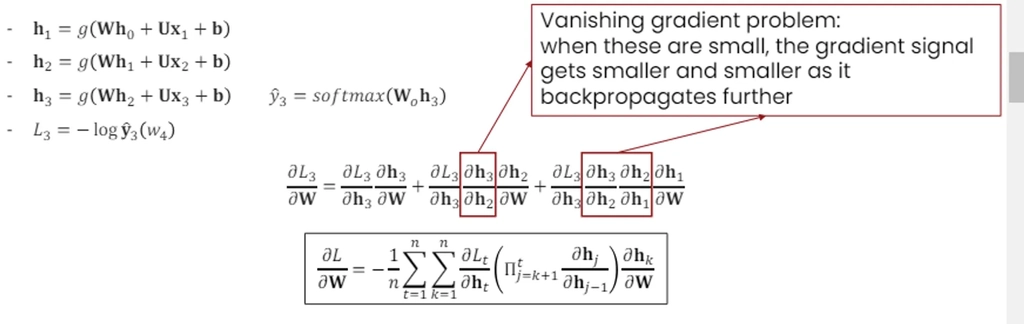
$$
\frac{\partial h_t}{\partial h_{t-1}} = \underbrace{\text{diag}\left(g'(a_t)\right)}_{\text{활성화 함수 미분값}} \ \times\underbrace{W_{hh}}_{\text{순환 가중치}}
$$

> ##### 기울기 소실
- 시퀀스 뒤쪽의 오차가 앞쪽까지 제대로 전달되지 않아 먼 과거의 정보를 학습하지 못하는 현상
- 역전파 과정에서 반복적으로 곱해지는 **기울기(미분값)의 크기가 1보다 작을 때**
    
    **⇒ 기울기가 0으로 수렴**

> ##### 기울기 폭주
- 시퀀스 뒤쪽의 오차가 역전파 과정에서 비정상적으로 커지는 문제
- 역전파 과정에서 반복적으로 곱해지는 **기울기(미분값)의 크기가 1보다 클 때**
    
    **⇒ 기울기가 무한대로 발산**


> ##### 느린 훈련 시간
- 계산 과정이 순차적으로 이루어져야만 하는 구조적 한계
- $t$ 시점의 은닉 상태($h_t$)를 계산하려면 $t-1$ 시점의 은닉 상태($h_{t-1}$)가 먼저 계산되어야 한다.
    
    ⇒ 이 의존성 때문에 전체 시퀀스를 한 번에 병렬 처리 불가능

> #### 장기 의존성 문제
- 위 세가지 RNN의 구조적 한계는 **‘장기 의존성 문제’**라는 하나의 치명적인 약점으로 이어진다.
- **시퀀스 앞 부분의 중요한 정보를 잊어버려 맥락 파악 능력이 급격히 저하되는 현상**
- 모델의 **‘단기 기억력’은 준수**했지만, **‘장기 기억력’에 문제** 발생

⇒ **새로운 모델**의 필요성 대두

- RNN의 **기억력 한계를 극복**
- **더 길고 복잡한 시퀀스 데이터를 안정적**으로 다룰 수 있는 새로운 대안
- **중요한 정보는 오래 기억**하고, **불필요한 정보는 잊는** 똑똑한 메모리 구조

# LSTM & GRU
## LSTM
- **셀 상태 $C_t$ - 장기 기억)**: 이 기억은 절대 변하지 않는 핵심 기억
- **엘리트 (은닉 상태 $h_t$ - 단기 기억/출력)**:  현재 상황에서 바로 사용하는 기억
- 셀 상태에서 필요한 정보만 꺼내서, 지금 시점에서의 판단이나 출력으로 사용
- LSTM 행동방식
    1. **“이 기억은 잊자” (Forget Gate)**: ($C_{t-1}$)는 잊어버리자!
    2. **“이건 기억하자” (Input Gate)**: ($x_t$)는 핵심 기억($C_t$)에 저장하자.
    3. **“이렇게 행동하자!” (Output Gate)**: ($C_t$)를 바탕으로, 결과 ($h_t$) 출력.
-  LSTM은 진짜 장기기억과 단기기억 및 출력을 따로 분리해서 관리
- 매우 정교하지만 그만큼 복잡

## GRU
- 모든 기억과 행동이 하나의 상태($h_t$)로 통합

- **과거 기억 vs 새 정보, 몇 대 몇? (Update Gate)**
    - ($h_{t-1}$)이 30% 있어도, ($x_t$)가  70% 더 중요
- **과거 기억은 얼마나 무시해야 할까? (Reset Gate)**
    - 새로운 자극이 강렬하면, 과거 기억은 잠시 무시
    - 방금 엄마한테 혼났지만($h_{t-1}$), 액션가면($x_t$)이 시작하네! → TV 앞으로 간다.

- GRU는 기억과 행동이 하나로 통합
- LSTM보다 훨씬 단순하고 즉각적인 반응
- STM에 비해 정교함은 떨어짐


# Seq2Seq
- 한 시퀀스를 다른 시퀀스로 변환하는 작업을 수행하는 딥러닝 모델로, 대표적으로 기계번역에서 사용
- 특징 1
    - 아이템(단어)의 입력 개수와 출력 개수가 같지 않아도 된다.
- 특징 2
    - 인코더와 디코더라는 모듈을 가지고 있어, Encoder-Decoder 모델이라고도 불린다. 

> ###  **인코더(Encoder): 의미를 정리하는 사람**
- 입력된 시퀀스를 읽고 압축하여 디코더에게 넘겨줄 문맥 정보 준비 (원문의 특징 파악)
    - ⇒ 여기서 압축된 정보는 **컨텍스트 벡터(context vector)** (요약 정보)
- 인코더에서는 t 시점의 임베딩된 단어의 입력과 t-1 시점의 은닉 상태(hidden state)가 RNN/LSTM의 입력으로 주어지며, 그 결과로 t시점의 은닉 상태가 나옴

> ### **디코더(Decoder): 그걸 받아서 결과를 만드는 사람**
- 압축된 정보를 바탕으로 원하는 시퀀스를 생성. (번역문 생성)
- 기본적인 seq2seq에서는, 인코더가 보내준 컨텍스트 벡터는 디코더의 첫번째 은닉 상태에 사용
- t시점에 나온 출력값이 그 다음 시점의 입력값으로 넘어감

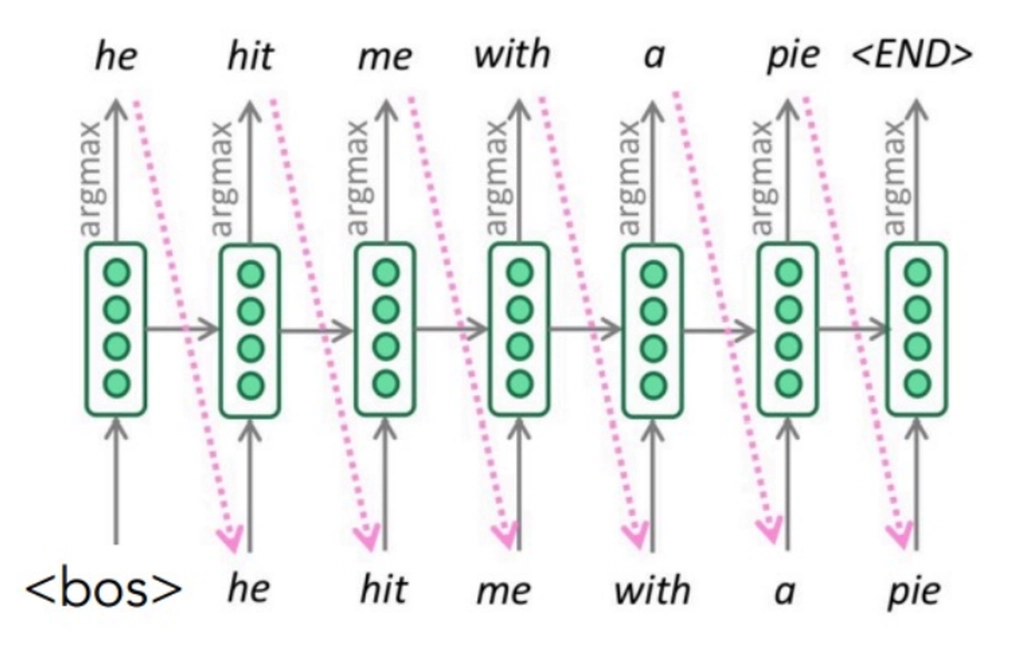
---
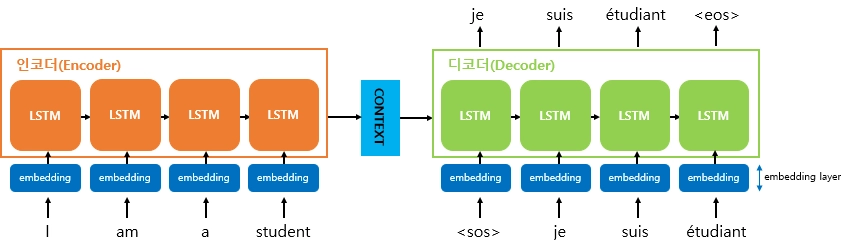
- 인코더와 디코더 모두 그림과 같이 **RNN(or LSTM/GRU)를 여러개 조합한 형태**
- 모든 단어는 워드 임베딩(word2vec) 과정을 거침

### Seq2Seq의 한계: 병목 현상 (Bottleneck)
- 고정된 Context Vector에 소스 문장의 정보 압축 → 병목 현상 발생
- 고정된 길이에 입력 시퀸스의 모든 정보를 담지 못하고 손실될 수 있다.
- 특히 긴 입력 시퀸스의 경우 정보 손실이 더 심각하며, 이는 모델 성능 하락으로 이어진다.